## EDA PROJECT ON SUPERSTORE_SALES_DATASET

### Introduction 

The Superstore Sales dataset is a widely used retail dataset from Kaggle that contains detailed information about customer orders, products, shipping details, and financial metrics such as sales, discounts, and profit. Each record represents a single transaction and includes important features like order date, ship date, customer segment, region, and product category.

This dataset consists of a large number of records with both numerical and categorical variables, making it suitable for comprehensive data analysis. It provides an opportunity to explore different aspects of business operations, including sales performance, customer purchasing behavior, and product demand across various regions.

In this Exploratory Data Analysis (EDA) project, the dataset is examined to identify patterns, trends, and relationships within the data. The analysis focuses on understanding sales and profit trends over time, comparing performance across regions and product categories, and evaluating the impact of discounts on profitability.

Various data analysis techniques such as data cleaning, summary statistics, and data visualization are used to gain insights. The findings from this analysis can help in making informed business decisions, improving sales strategies, and enhancing overall performance.


#### Import Necessary Libraries

In [1]:
#remove warning messages
import warnings
warnings.filterwarnings('ignore')

#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

#### Import Dataset

In [2]:
df = pd.read_csv('Superstore.csv', encoding='cp1252')

##### Display the first 5 rows

In [3]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##### Display the last 5 rows

In [4]:
df.tail(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2011-110422,22-01-2011,24-01-2011,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2014-121258,27-02-2014,04-03-2014,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2014-119914,05-05-2014,10-05-2014,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


#### Data Cleaning

In [5]:
#Convert column name to standard type

df.columns = (df.columns
              .str.strip()
              .str.title()
              .str.replace(" ","_")
              .str.replace("-","_")
              )

In [6]:
#Convert date columns to date format

df['Order_Date'] = pd.to_datetime(df['Order_Date'], format="%d-%m-%Y")
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

In [7]:
#Check whether ther is missing values

print(df.isnull().sum())

Row_Id           0
Order_Id         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_Id      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_Id       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
#Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [9]:
#Drop column which is not at all necessary
df.drop(columns=['Row_Id', 'Customer_Id','Postal_Code'] ,inplace=True)

#### Data Understanding

In [10]:
#Basic Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_Id       9994 non-null   object        
 1   Order_Date     9994 non-null   datetime64[ns]
 2   Ship_Date      9994 non-null   datetime64[ns]
 3   Ship_Mode      9994 non-null   object        
 4   Customer_Name  9994 non-null   object        
 5   Segment        9994 non-null   object        
 6   Country        9994 non-null   object        
 7   City           9994 non-null   object        
 8   State          9994 non-null   object        
 9   Region         9994 non-null   object        
 10  Product_Id     9994 non-null   object        
 11  Category       9994 non-null   object        
 12  Sub_Category   9994 non-null   object        
 13  Product_Name   9994 non-null   object        
 14  Sales          9994 non-null   float64       
 15  Quantity       9994 n

In [11]:
# Use summary statistics to understand distribution
df.describe()

,Order_Date,Ship_Date,Sales,Quantity,Discount,Profit
count,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,2013-04-30 19:20:02.401441024,2013-05-04 18:20:49.229537792,229.858001,3.789574,0.156203,28.656896
min,2011-01-04 00:00:00,2011-01-08 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2012-05-23 00:00:00,2012-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,2013-06-27 00:00:00,2013-06-30 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,2014-05-15 00:00:00,2014-05-19 00:00:00,209.940000,5.000000,0.200000,29.364000
max,2014-12-31 00:00:00,2015-01-06 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,NaN,NaN,623.245101,2.225110,0.206452,234.260108


###  Data Analysis and visualization

1. What is the total sales and total profit in the dataset?

In [12]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
print("Total sales : ",total_sales, "\nTotal Profit : ", total_profit)


Total sales :  2297200.8603000003 
Total Profit :  286397.0217


2. Which region generates the highest sales?

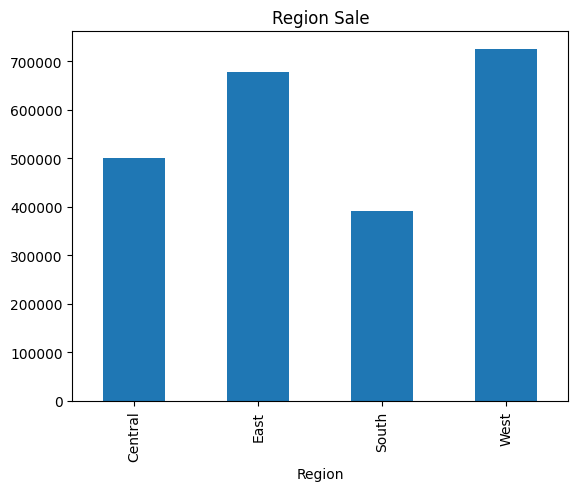

West Region Generate highest Sale of 725457.8245


In [13]:
region_sale = df.groupby('Region')['Sales'].sum()

region_sale.plot(kind='bar')
plt.title('Region Sale')
plt.show()

print(f'{region_sale.idxmax()} Region Generate highest Sale of {region_sale.max()}')

3. What are the top 10 cities by sales?

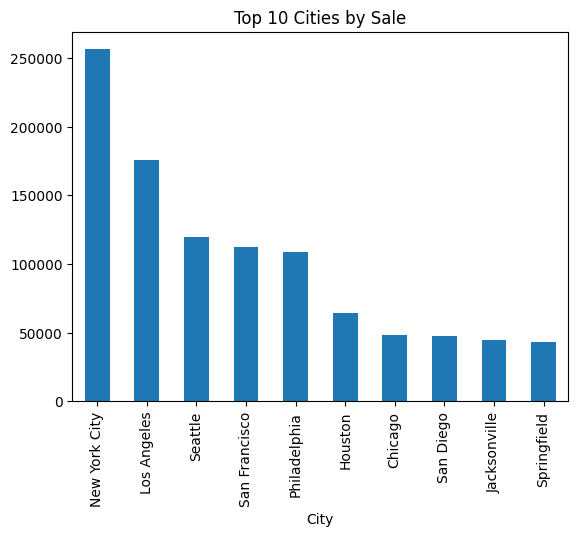

New York City has the highest sales among all cities, showing it is a major contributor to overall revenue.


In [14]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Sale")
plt.show()

top_city = top_cities.idxmax()
print(f"{top_city} has the highest sales among all cities, showing it is a major contributor to overall revenue.")

4. How do sales vary over time (monthly trend)?

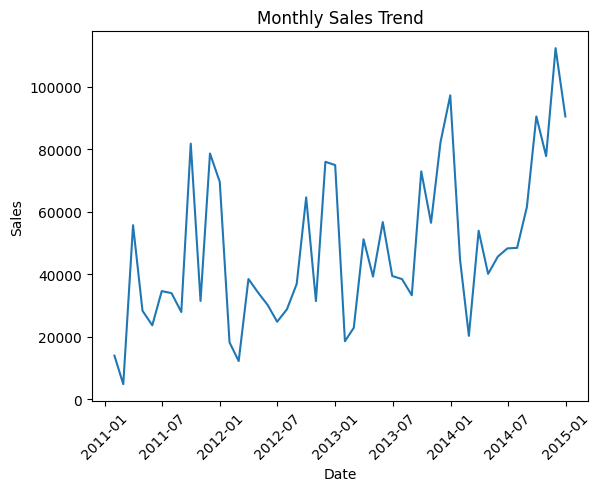

Conclusion:
Sales show an overall increasing trend over time with some fluctuations.


In [15]:
# monthly sales
monthly_sales = df.resample('M', on='Order_Date')['Sales'].sum()

# plot
plt.plot(monthly_sales)
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# conclusion (dynamic)
print("Conclusion:")

if monthly_sales.iloc[-1] > monthly_sales.iloc[0]:
    print("Sales show an overall increasing trend over time with some fluctuations.")
else:
    print("Sales fluctuate over time without a consistent upward trend.")

5. Which month has the highest sales?

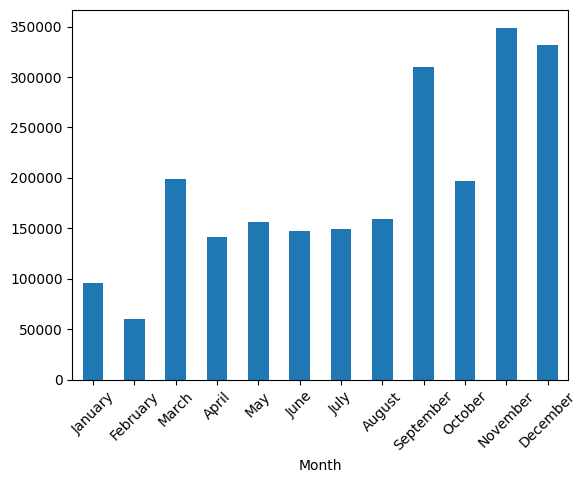

Highest Sale :  349120.074
On :  November


In [16]:
# get month names
df['Month'] = df['Order_Date'].dt.month_name()

# group by month
monthly_sales = df.groupby('Month')['Sales'].sum()

# correct month order
order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']

monthly_sales = monthly_sales.reindex(order)

# plot
monthly_sales.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

# highest month
print("Highest Sale : ",monthly_sales.max())
print("On : ", monthly_sales.idxmax())

6. Which category contributes the most to sales? 

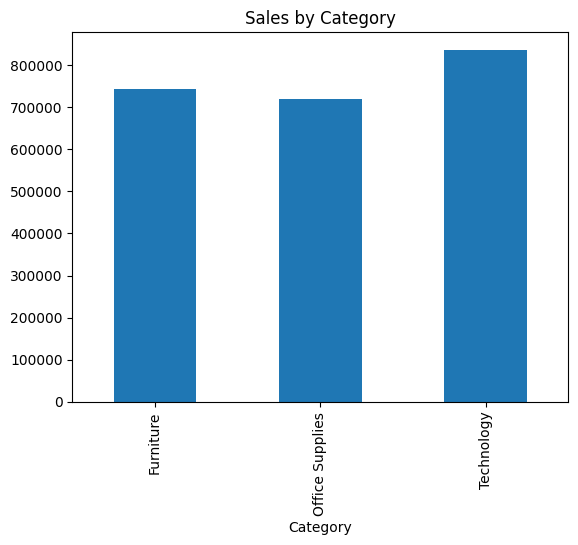

Category Contribute most : Technology
Sale :  836154.033


In [17]:
category_sale = df.groupby('Category')['Sales'].sum()

top_category = category_sale.idxmax()
top_category_sale = category_sale.max()

category_sale.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

print('Category Contribute most :' , top_category)
print('Sale : ', top_category_sale)

7. Which sub-category generates the highest and lowest profit?

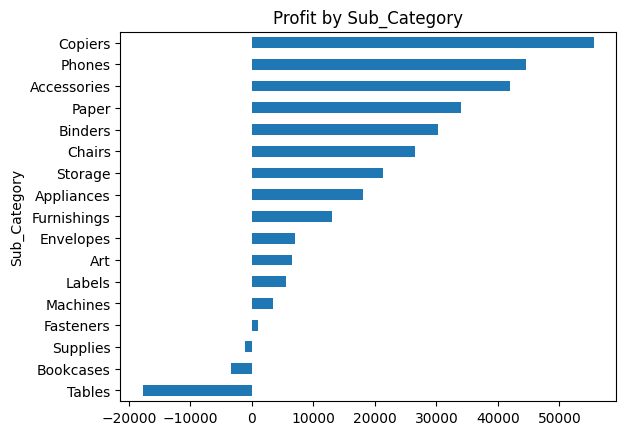

Copiers generate Highest profit of 55617.8249
Tables generate Lowest profit of -17725.4811


In [18]:
subcategory_sale = df.groupby('Sub_Category')['Profit'].sum().sort_values()

subcategory_sale.plot(kind='barh')
plt.title("Profit by Sub_Category")
plt.show()

highest = subcategory_sale.idxmax()
lowest = subcategory_sale.idxmin()

print(f"{highest} generate Highest profit of {subcategory_sale.max()}")
print(f"{lowest} generate Lowest profit of {subcategory_sale.min()}")

8. What are the top 10 most profitable products?

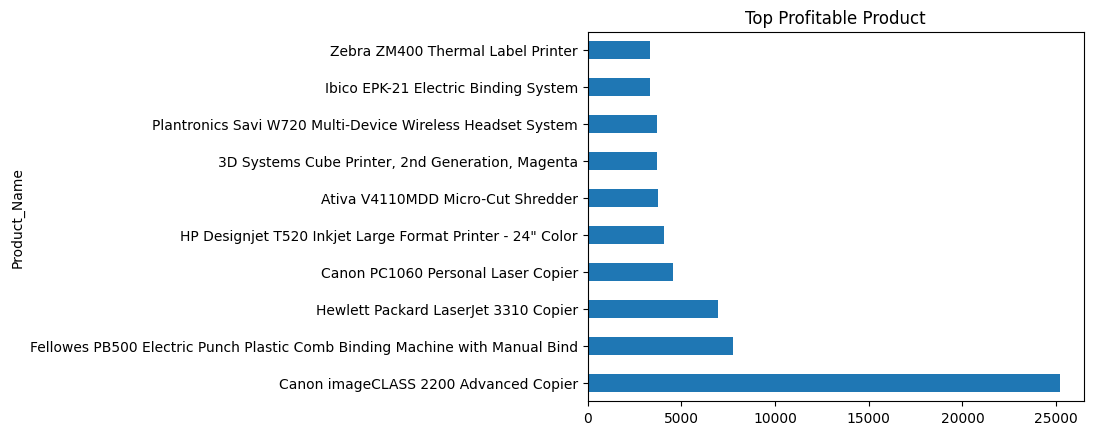

In [19]:
top_profit_product = df.groupby('Product_Name')['Profit'].sum().sort_values(ascending=False).head(10)

top_profit_product.plot(kind='barh')
plt.title('Top Profitable Product')
plt.show()

9. How does discount affect profit?

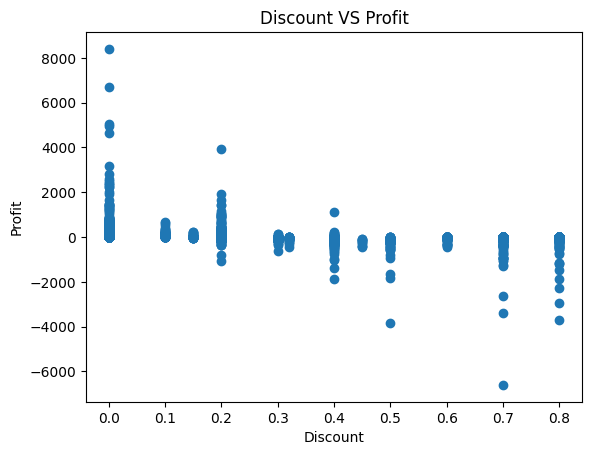

The scatter plot shows a negative relationship between discount and profit.
Higher discounts tend to reduce profit, and in many cases lead to losses.


In [20]:
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount VS Profit")
plt.show()


print('The scatter plot shows a negative relationship between discount and profit'
'.\nHigher discounts tend to reduce profit, and in many cases lead to losses.')

10. Which shipping mode is used most frequently?

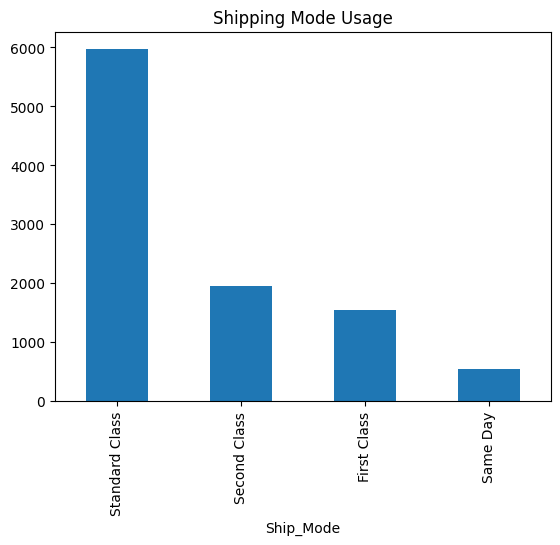

Mostly used Ship Mode is Standard Class


In [21]:
ship_mode = df['Ship_Mode'].value_counts()

ship_mode.plot(kind="bar")
plt.title("Shipping Mode Usage")
plt.show()

print(f"Mostly used Ship Mode is {ship_mode.idxmax()}")

11.What is the correlation between numerical variables?

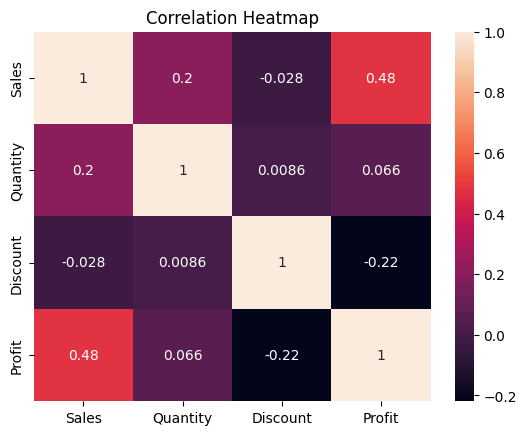

Conclusion:
Sales and Profit are positively correlated.
Discount negatively affects Profit.


In [22]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

print("Conclusion:")

if corr.loc['Sales','Profit'] > 0:
    print("Sales and Profit are positively correlated.")
else:
    print("Sales and Profit are negatively correlated.")

if corr.loc['Discount','Profit'] < 0:
    print("Discount negatively affects Profit.")

12. How do sales and profit compare across regions?

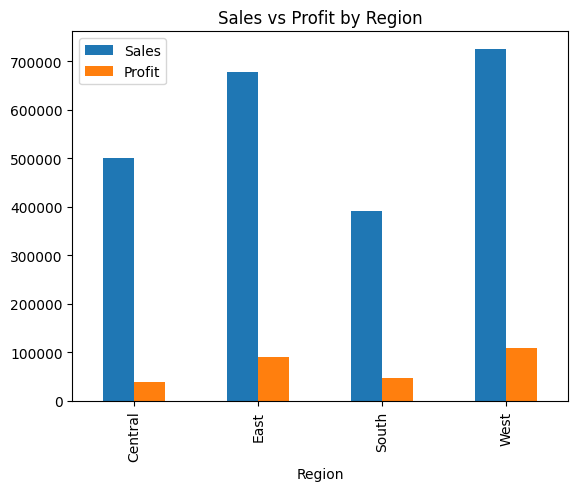

Conclusion:
West has the highest sales.
West has the highest profit.


In [23]:
region_data = df.groupby('Region')[['Sales', 'Profit']].sum()

region_data.plot(kind='bar')
plt.title('Sales vs Profit by Region')
plt.show()

top_sales_region = region_data['Sales'].idxmax()
top_profit_region = region_data['Profit'].idxmax()

print("Conclusion:")
print(f"{top_sales_region} has the highest sales.")
print(f"{top_profit_region} has the highest profit.")

13. Which sub-categories generate high sales but low or negative profit ?

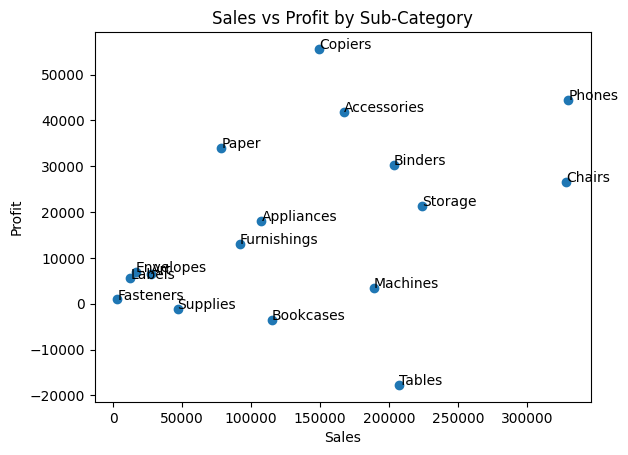

Inefficient Sub-Categories:
                   Sales      Profit
Sub_Category                        
Tables        206965.532 -17725.4811


In [24]:
sub_data = df.groupby('Sub_Category')[['Sales', 'Profit']].sum()

plt.scatter(sub_data['Sales'], sub_data['Profit'])

for i, txt in enumerate(sub_data.index):
    plt.annotate(txt, (sub_data['Sales'][i], sub_data['Profit'][i]))

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit by Sub-Category")
plt.show()

# find inefficient sub-categories
high_sales = sub_data['Sales'].quantile(0.75)

inefficient = sub_data[
    (sub_data['Sales'] >= high_sales) & 
    (sub_data['Profit'] <= 0)
]

print("Inefficient Sub-Categories:")
print(inefficient)

## Conclusion

The analysis shows that the West region generates the highest sales, while the East/West region also performs well in terms of profit, indicating strong business performance in these areas.

Among cities, New York City contributes the highest sales, making it a key revenue-generating location.

The correlation analysis indicates that Sales and Profit are positively related, while Discount has a negative impact on Profit, meaning higher discounts reduce profitability.

Monthly sales analysis shows fluctuations over time with an overall increasing trend, suggesting growth along with seasonal variations.

At the product level, some sub-categories such as Tables show high sales but low or negative profit, indicating inefficiency due to high costs or heavy discounts.

Overall, the business should focus on reducing excessive discounts, improving low-profit sub-categories, and strengthening high-performing regions to increase profitability.